In [ ]:
from datetime import datetime

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.feature_selection import (
    RFECV,
)
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import KFold, train_test_split
from xgboost import XGBRegressor

In [ ]:
DATA_PREFIX = "../data"
OUTPUT_PREFIX = "../output"

EXTRACT_TRAIN_PARQUET = f"{OUTPUT_PREFIX}/extract_train_v2.parquet"
EXTRACT_TEST_PARQUET = f"{OUTPUT_PREFIX}/extract_test_v2.parquet"
SUBMISSION_CSV = f"{DATA_PREFIX}/sample_submission.csv"


In [ ]:
BANDS_S2 = ["BLUE", "GREEN", "RED", "NIR", "SWIR1", "SWIR2"]
# BANDS_S2_DIST = [f"{b}_DIST" for b in BANDS_S2]
BANDS_S1 = ["VV", "VH"]
BANDS_CHM = [
    # "CHM",
    "CHM_META",
    # "CHM_ETH",
    "CHM_ALS",
    # "CHM_META_5M"
]
BANDS_TERRAIN = [
    # "elevation",
    "slope",
    "aspect",
    "tpi",
    "tri",
    "hillshade",
]
BANDS_LST = ["LST"]
BANDS_TREE = ["CANOPY_DENSITY", "TREE_RATIO", "LEAF_TYPE"]
BANDS_AGB = ["AGB_GEDI", "AGB_ALS"]
BANDS_EMBEDDING = [f"A{n}" for n in range(64)]
# BANDS_S1_DIST = [f"{b}_DIST" for b in BANDS_S1]

INDICES = [
    dict(name="NDVI", band1="NIR", band2="RED"),
    dict(name="NDMI", band1="NIR", band2="SWIR1"),
    dict(name="NBR", band1="NIR", band2="SWIR2"),
    dict(name="NBR2", band1="SWIR1", band2="SWIR2"),
    dict(name="NDWI", band1="GREEN", band2="NIR"),
    dict(name="MNDWI", band1="GREEN", band2="SWIR1"),
    dict(name="MNDWI2", band1="GREEN", band2="SWIR2"),
    dict(name="RVI", band1="VV", band2="VH"),
]

INDICES_BANDS = [indi["name"] for indi in INDICES]
# INDICES_BANDS_DIST = [f"{b}_DIST" for b in INDICES_BANDS]

PREDICTORS = [
    *BANDS_S2,
    *BANDS_S1,
    *INDICES_BANDS,
    *BANDS_CHM,
    *BANDS_TREE,
    *BANDS_TERRAIN,
    *BANDS_LST,
    *BANDS_AGB,
    # *BANDS_S2_DIST,
    # *BANDS_S1_DIST,
    # *INDICES_BANDS_DIST,
]

LABEL = "biomass"

PREDICTORS

['BLUE',
 'GREEN',
 'RED',
 'NIR',
 'SWIR1',
 'SWIR2',
 'VV',
 'VH',
 'NDVI',
 'NDMI',
 'NBR',
 'NBR2',
 'NDWI',
 'MNDWI',
 'MNDWI2',
 'RVI',
 'CHM_META',
 'CHM_ALS',
 'CANOPY_DENSITY',
 'TREE_RATIO',
 'LEAF_TYPE',
 'slope',
 'aspect',
 'tpi',
 'tri',
 'hillshade',
 'LST',
 'AGB_GEDI',
 'AGB_ALS']

In [ ]:
# load parquet extracted
train_df = gpd.read_parquet(EXTRACT_TRAIN_PARQUET).dropna()
train_df

,x,y,year,biomass,tile_id,geometry,BLUE,GREEN,RED,NIR,...,A59,A60,A61,A62,A63,AGB_GEDI,AGB_ALS,TREE_RATIO,CHM_META_5M,LEAF_TYPE
0,3137124.7416963745,1810803.9191588927,2020,28.742064,038052,POINT (-3.54712 38.43217),366.0,588.0,620.0,2545.0,...,-60,56,-10,8,-36,113.301270,56.061787,0.259686,3,2
1,3138084.7416963745,1808543.9191588927,2020,61.379017,038052,POINT (-3.53221 38.41357),305.0,540.0,401.0,3402.0,...,-55,52,-38,31,39,73.137436,75.136459,0.270767,7,1
2,3136834.7416963745,1809903.9191588927,2020,41.445705,038052,POINT (-3.54874 38.42368),464.0,710.0,748.0,2929.0,...,-62,52,-26,26,0,74.259979,59.050060,0.278183,6,1
3,3137594.7416963745,1810823.9191588927,2020,25.911734,038052,POINT (-3.54186 38.4331),622.0,848.0,1139.0,2380.0,...,-47,66,-32,32,16,94.649872,66.291756,0.245272,0,1
4,3137914.7416963745,1808923.9191588927,2020,40.892021,038052,POINT (-3.53481 38.41668),281.0,514.0,387.0,2421.0,...,-48,57,-21,-29,14,74.906807,56.946735,0.258520,6,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5148498,3111814.7416963745,2243943.9191588927,2019,96.743500,035805,POINT (-4.70358 42.23347),371.0,607.0,566.0,2937.0,...,-53,50,-57,0,-41,80.114174,82.793846,0.421154,3,1
5148499,3111664.7416963745,2243933.9191588927,2019,58.634174,035805,POINT (-4.70534 42.23312),882.0,1252.0,1425.0,3500.0,...,-49,58,-61,18,-19,68.616600,63.931862,0.406098,0,1
5148501,3113104.7416963745,2243803.9191588927,2019,118.166924,035805,POINT (-4.68791 42.2345),380.0,564.0,578.0,3241.0,...,-40,40,-64,-31,-35,86.218414,93.326202,0.181319,5,1
5148502,3113074.7416963745,2243833.9191588927,2019,104.021767,035805,POINT (-4.68834 42.23471),307.0,510.0,479.0,3084.0,...,-47,37,-62,-32,-29,88.159515,96.633919,0.285560,6,1


In [ ]:
# Generating indices
def generate_indices(table, band_suffix=""):
    for index_dict in INDICES:
        name = f"{index_dict['name']}{band_suffix}"
        band1 = f"{index_dict['band1']}{band_suffix}"
        band2 = f"{index_dict['band2']}{band_suffix}"
        table[name] = (
            ((table[band1] / 1e4) - (table[band2] / 1e4))
            / ((table[band1] / 1e4) + (table[band2] / 1e4))
            * 1e4
        )


generate_indices(train_df)
# generate_indices(train_df, "_DIST")

train_df

,x,y,year,biomass,tile_id,geometry,BLUE,GREEN,RED,NIR,...,CHM_META_5M,LEAF_TYPE,NDVI,NDMI,NBR,NBR2,NDWI,MNDWI,MNDWI2,RVI
0,3137124.7416963745,1810803.9191588927,2020,28.742064,038052,POINT (-3.54712 38.43217),366.0,588.0,620.0,2545.0,...,3,2,6082.148499,953.303206,3286.348212,2408.500590,-6246.409192,-5628.252788,-3724.653148,5634.005764
1,3138084.7416963745,1808543.9191588927,2020,61.379017,038052,POINT (-3.53221 38.41357),305.0,540.0,401.0,3402.0,...,7,1,7891.138575,2368.660244,5231.699127,3268.015171,-7260.273973,-5907.540735,-3271.028037,5745.654163
2,3136834.7416963745,1809903.9191588927,2020,41.445705,038052,POINT (-3.54874 38.42368),464.0,710.0,748.0,2929.0,...,6,1,5931.465869,908.752328,3172.925568,2331.396817,-6097.829074,-5493.494129,-3626.570916,5230.875258
3,3137594.7416963745,1810823.9191588927,2020,25.911734,038052,POINT (-3.54186 38.4331),622.0,848.0,1139.0,2380.0,...,0,1,3526.570048,-428.312890,1646.684610,2060.465116,-4745.972739,-5071.200232,-3362.035225,4729.829756
4,3137914.7416963745,1808923.9191588927,2020,40.892021,038052,POINT (-3.53481 38.41668),281.0,514.0,387.0,2421.0,...,6,2,7243.589744,2396.313364,4677.174901,2568.768515,-6497.444634,-4857.428714,-2614.942529,4161.585366
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5148498,3111814.7416963745,2243943.9191588927,2019,96.743500,035805,POINT (-4.70358 42.23347),371.0,607.0,566.0,2937.0,...,3,1,6768.484156,1165.177723,3695.500117,2644.178455,-6574.492099,-5858.068918,-3802.960694,4750.430293
5148499,3111664.7416963745,2243933.9191588927,2019,58.634174,035805,POINT (-4.70534 42.23312),882.0,1252.0,1425.0,3500.0,...,0,1,4213.197970,1301.259283,3425.393172,2223.230490,-4730.639731,-3654.333502,-1557.653405,6197.623515
5148501,3113104.7416963745,2243803.9191588927,2019,118.166924,035805,POINT (-4.68791 42.2345),380.0,564.0,578.0,3241.0,...,5,1,6973.029589,1990.381058,4546.678636,2810.650888,-7035.479632,-5866.617809,-3659.359191,4710.860367
5148502,3113074.7416963745,2243833.9191588927,2019,104.021767,035805,POINT (-4.68834 42.23471),307.0,510.0,479.0,3084.0,...,6,1,7311.254561,2233.240777,4431.445952,2439.644219,-7161.936561,-5867.098865,-4000.000000,5334.750266


In [ ]:
train_df_filter = train_df[(train_df["BLUE"] > 0) & (train_df["VV"] > 0)]
train_df_filter

,x,y,year,biomass,tile_id,geometry,BLUE,GREEN,RED,NIR,...,CHM_META_5M,LEAF_TYPE,NDVI,NDMI,NBR,NBR2,NDWI,MNDWI,MNDWI2,RVI
0,3137124.7416963745,1810803.9191588927,2020,28.742064,038052,POINT (-3.54712 38.43217),366.0,588.0,620.0,2545.0,...,3,2,6082.148499,953.303206,3286.348212,2408.500590,-6246.409192,-5628.252788,-3724.653148,5634.005764
1,3138084.7416963745,1808543.9191588927,2020,61.379017,038052,POINT (-3.53221 38.41357),305.0,540.0,401.0,3402.0,...,7,1,7891.138575,2368.660244,5231.699127,3268.015171,-7260.273973,-5907.540735,-3271.028037,5745.654163
2,3136834.7416963745,1809903.9191588927,2020,41.445705,038052,POINT (-3.54874 38.42368),464.0,710.0,748.0,2929.0,...,6,1,5931.465869,908.752328,3172.925568,2331.396817,-6097.829074,-5493.494129,-3626.570916,5230.875258
3,3137594.7416963745,1810823.9191588927,2020,25.911734,038052,POINT (-3.54186 38.4331),622.0,848.0,1139.0,2380.0,...,0,1,3526.570048,-428.312890,1646.684610,2060.465116,-4745.972739,-5071.200232,-3362.035225,4729.829756
4,3137914.7416963745,1808923.9191588927,2020,40.892021,038052,POINT (-3.53481 38.41668),281.0,514.0,387.0,2421.0,...,6,2,7243.589744,2396.313364,4677.174901,2568.768515,-6497.444634,-4857.428714,-2614.942529,4161.585366
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5148498,3111814.7416963745,2243943.9191588927,2019,96.743500,035805,POINT (-4.70358 42.23347),371.0,607.0,566.0,2937.0,...,3,1,6768.484156,1165.177723,3695.500117,2644.178455,-6574.492099,-5858.068918,-3802.960694,4750.430293
5148499,3111664.7416963745,2243933.9191588927,2019,58.634174,035805,POINT (-4.70534 42.23312),882.0,1252.0,1425.0,3500.0,...,0,1,4213.197970,1301.259283,3425.393172,2223.230490,-4730.639731,-3654.333502,-1557.653405,6197.623515
5148501,3113104.7416963745,2243803.9191588927,2019,118.166924,035805,POINT (-4.68791 42.2345),380.0,564.0,578.0,3241.0,...,5,1,6973.029589,1990.381058,4546.678636,2810.650888,-7035.479632,-5866.617809,-3659.359191,4710.860367
5148502,3113074.7416963745,2243833.9191588927,2019,104.021767,035805,POINT (-4.68834 42.23471),307.0,510.0,479.0,3084.0,...,6,1,7311.254561,2233.240777,4431.445952,2439.644219,-7161.936561,-5867.098865,-4000.000000,5334.750266


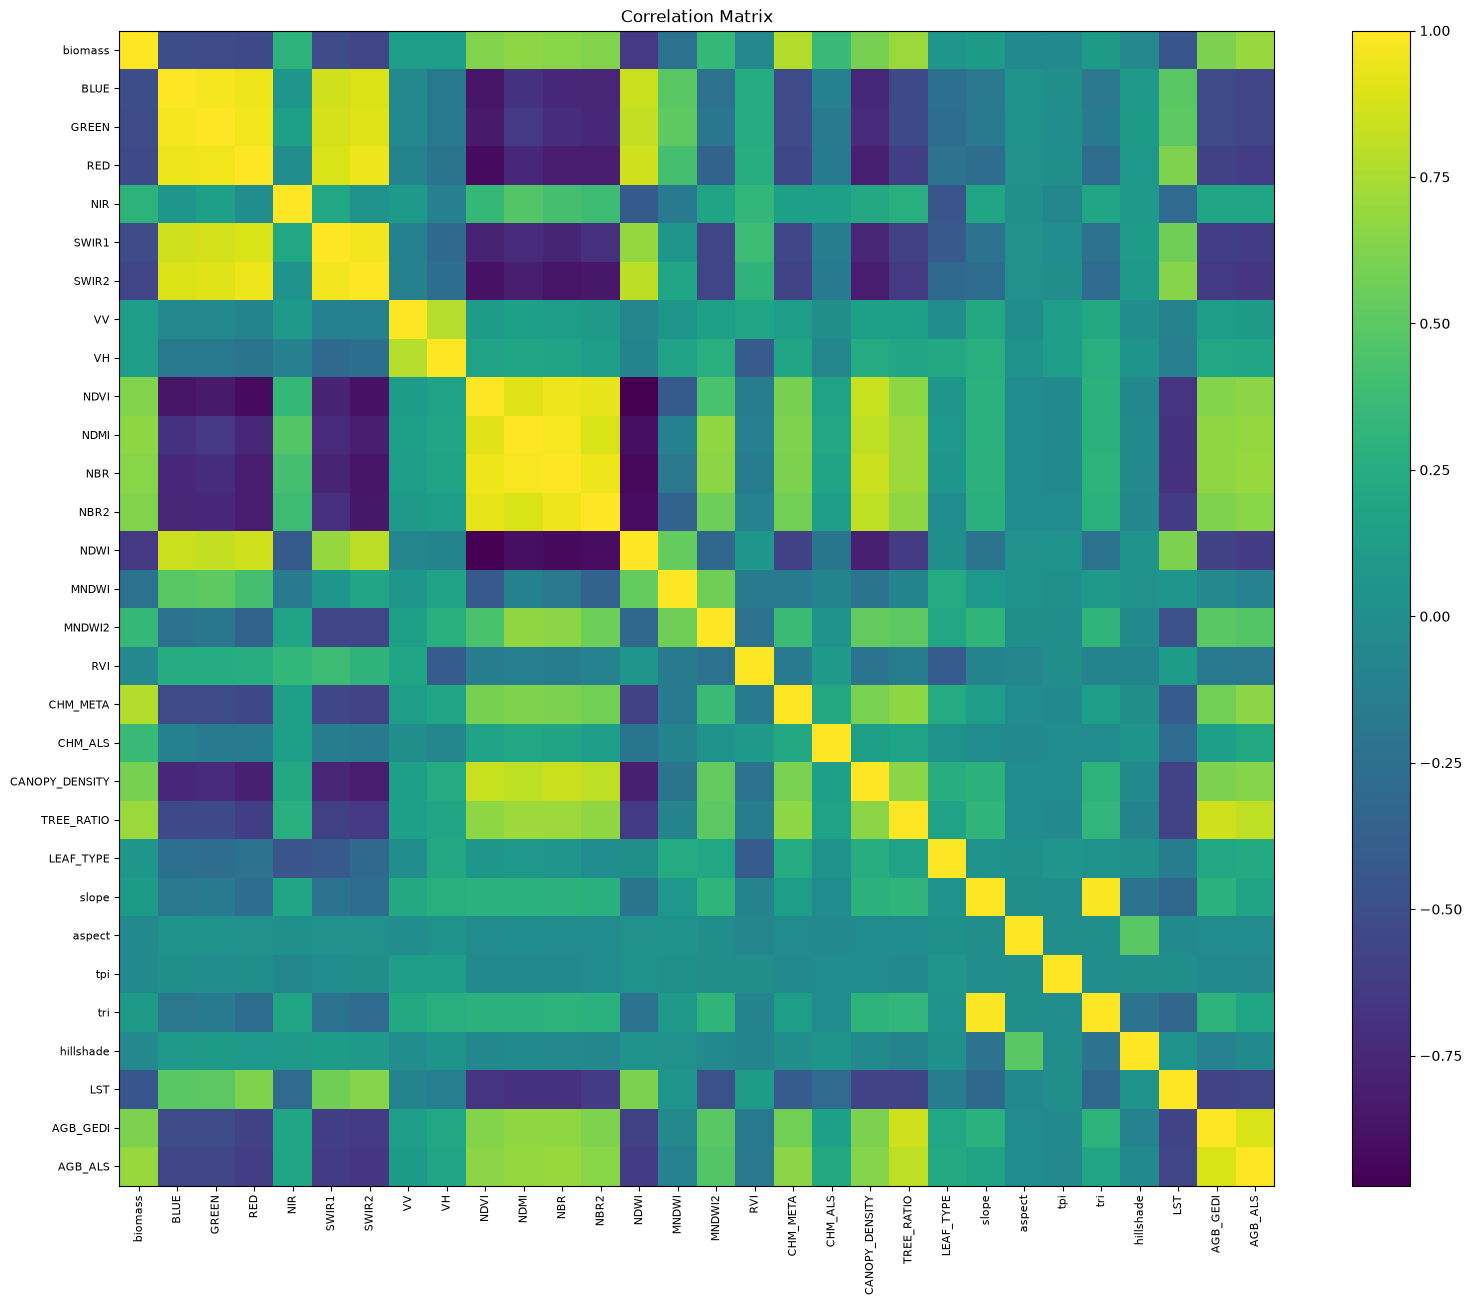

In [ ]:
# generate correlation matrix
correlation = train_df[[LABEL, *PREDICTORS]].corr()

plt.figure(figsize=(20, 15))
plt.imshow(correlation)
plt.title("Correlation Matrix")
plt.xticks(range(len([LABEL, *PREDICTORS])), [LABEL, *PREDICTORS], size=8, rotation=90)
plt.yticks(range(len([LABEL, *PREDICTORS])), [LABEL, *PREDICTORS], size=8)
plt.colorbar()
plt.show()


In [ ]:
# split train and test data
train, test = train_test_split(train_df_filter, test_size=0.5)

In [ ]:
SELECTED_PREDICTORS = PREDICTORS + BANDS_EMBEDDING

In [ ]:
MODEL_NAME = f"LGBM_v1_{datetime.now().timestamp()}"
model = XGBRegressor(n_estimators=100, max_depth=16)
model.fit(train[SELECTED_PREDICTORS], train[LABEL])

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.053507 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14446
[LightGBM] [Info] Number of data points in the train set: 133176, number of used features: 93
[LightGBM] [Info] Start training from score 163.978380


,n_estimators,1000
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [ ]:
total = sum(model.feature_importances_)
print("Feature importance")
dict(zip(model.feature_names_in_, model.feature_importances_ / total * 100))

Feature importance


{np.str_('BLUE'): np.float64(0.8366666666666667),
 np.str_('GREEN'): np.float64(0.8099999999999999),
 np.str_('RED'): np.float64(0.75),
 np.str_('NIR'): np.float64(1.3299999999999998),
 np.str_('SWIR1'): np.float64(1.1199999999999999),
 np.str_('SWIR2'): np.float64(0.8333333333333334),
 np.str_('VV'): np.float64(1.0533333333333335),
 np.str_('VH'): np.float64(1.0),
 np.str_('NDVI'): np.float64(1.1033333333333333),
 np.str_('NDMI'): np.float64(0.7833333333333333),
 np.str_('NBR'): np.float64(0.5233333333333334),
 np.str_('NBR2'): np.float64(1.0999999999999999),
 np.str_('NDWI'): np.float64(1.5666666666666667),
 np.str_('MNDWI'): np.float64(0.7366666666666666),
 np.str_('MNDWI2'): np.float64(0.74),
 np.str_('RVI'): np.float64(0.5533333333333333),
 np.str_('CHM_META'): np.float64(2.36),
 np.str_('CHM_ALS'): np.float64(1.7399999999999998),
 np.str_('CANOPY_DENSITY'): np.float64(0.89),
 np.str_('TREE_RATIO'): np.float64(1.6099999999999999),
 np.str_('LEAF_TYPE'): np.float64(0.21333333333333

In [ ]:
test_apply = model.predict(test[SELECTED_PREDICTORS])
r2 = np.corrcoef(test[LABEL], test_apply)[0, 1] ** 2
mae = mean_absolute_error(test[LABEL], test_apply)
rmse = root_mean_squared_error(test[LABEL], test_apply)
print(f"R^2={r2}", f"MAE={mae}", f"RMSE={rmse}")

R^2=0.8575202586570251 MAE=14.409809555008453 RMSE=21.36712493528998


In [ ]:
test_df = gpd.read_parquet(EXTRACT_TEST_PARQUET)
test_df

,row_id,tile_id,x,y,year,geometry,BLUE,GREEN,RED,NIR,...,A59,A60,A61,A62,A63,AGB_ALS,AGB_GEDI,TREE_RATIO,CHM_META_5M,LEAF_TYPE
0,028631_3040064_2251003,028631,3040064.7416963745,2251003.9191588927,2021,POINT (-5.57242 42.1662),147.0,318.0,152.0,3368.0,...,-33,46,-58,-32,-50,156.377869,140.037521,0.743050,17,1
1,028631_3041214_2252063,028631,3041214.7416963745,2252063.9191588927,2021,POINT (-5.56121 42.17768),155.0,318.0,167.0,3011.0,...,-39,42,-65,-33,-25,165.076569,98.719131,0.394708,23,1
2,028631_3041184_2251693,028631,3041184.7416963745,2251693.9191588927,2021,POINT (-5.56071 42.17436),159.0,330.0,148.0,4007.0,...,-36,27,-69,-37,-36,157.325394,149.595123,0.815218,10,1
3,028631_3039864_2250783,028631,3039864.7416963745,2250783.9191588927,2021,POINT (-5.57428 42.16389),163.0,329.0,167.0,3221.0,...,-43,52,-64,-19,-45,156.004425,143.666931,0.784128,22,1
4,028631_3040224_2251483,028631,3040224.7416963745,2251483.9191588927,2021,POINT (-5.57163 42.17073),139.0,276.0,123.0,4183.0,...,-40,44,-65,-41,-37,152.895508,132.243729,0.782894,15,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45014,061751_3374644_2043173,061751,3374644.7416963745,2043173.9191588927,2020,POINT (-1.21909 40.85472),289.0,583.0,396.0,4034.0,...,-41,61,-64,-27,-33,94.936523,73.033913,0.240762,0,1
45015,061751_3374594_2043203,061751,3374594.7416963745,2043203.9191588927,2020,POINT (-1.21972 40.85492),686.0,1111.0,1201.0,4128.0,...,-39,59,-68,26,-14,165.611465,165.594070,0.369998,6,1
45016,061751_3374624_2043173,061751,3374624.7416963745,2043173.9191588927,2020,POINT (-1.21932 40.85469),286.0,574.0,375.0,3594.0,...,-43,61,-64,-27,-34,165.611465,165.594070,0.283173,14,1
45017,061751_3374614_2043223,061751,3374614.7416963745,2043223.9191588927,2020,POINT (-1.21952 40.85512),210.0,405.0,271.0,3095.0,...,-51,64,-63,-3,-17,165.611465,165.594070,0.420182,15,1


In [ ]:
generate_indices(test_df)
# generate_indices(test_df, "_DIST")
test_df

,row_id,tile_id,x,y,year,geometry,BLUE,GREEN,RED,NIR,...,CHM_META_5M,LEAF_TYPE,NDVI,NDMI,NBR,NBR2,NDWI,MNDWI,MNDWI2,RVI
0,028631_3040064_2251003,028631,3040064.7416963745,2251003.9191588927,2021,POINT (-5.57242 42.1662),147.0,318.0,152.0,3368.0,...,17,1,9136.363636,4451.834370,7144.311530,3948.220065,-8274.552360,-6052.141527,-2764.505119,6313.488059
1,028631_3041214_2252063,028631,3041214.7416963745,2252063.9191588927,2021,POINT (-5.56121 42.17768),155.0,318.0,167.0,3011.0,...,23,1,8949.024544,4112.959925,6963.380282,3994.428969,-8089.516371,-5959.339263,-2578.763127,5957.873621
2,028631_3041184_2251693,028631,3041184.7416963745,2251693.9191588927,2021,POINT (-5.56071 42.17436),159.0,330.0,148.0,4007.0,...,10,1,9287.605295,5477.018154,7836.634765,4133.977067,-8478.210745,-5602.931379,-1911.764706,5052.573326
3,028631_3039864_2250783,028631,3039864.7416963745,2250783.9191588927,2021,POINT (-5.57428 42.16389),163.0,329.0,167.0,3221.0,...,22,1,9014.167651,4192.553426,7042.328042,4043.686734,-8146.478873,-6004.857316,-2590.090090,5794.743429
4,028631_3040224_2251483,028631,3040224.7416963745,2251483.9191588927,2021,POINT (-5.57163 42.17073),139.0,276.0,123.0,4183.0,...,15,1,9428.704134,5599.477904,8131.772865,4649.286158,-8762.054272,-6208.791209,-2192.362093,6947.230702
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45014,061751_3374644_2043173,061751,3374644.7416963745,2043173.9191588927,2020,POINT (-1.21909 40.85472),289.0,583.0,396.0,4034.0,...,0,1,8212.189616,3183.006536,5491.551459,2797.546012,-7474.550574,-5631.322593,-3363.688105,5631.067961
45015,061751_3374594_2043203,061751,3374594.7416963745,2043203.9191588927,2020,POINT (-1.21972 40.85492),686.0,1111.0,1201.0,4128.0,...,6,1,5492.587728,1806.091806,3446.254072,1749.026041,-5758.732583,-4411.468813,-2885.046430,5997.161107
45016,061751_3374624_2043173,061751,3374624.7416963745,2043173.9191588927,2020,POINT (-1.21932 40.85469),286.0,574.0,375.0,3594.0,...,14,1,8110.355253,2575.227432,4937.655860,2706.586826,-7245.681382,-5741.839763,-3593.750000,5781.990521
45017,061751_3374614_2043223,061751,3374614.7416963745,2043223.9191588927,2020,POINT (-1.21952 40.85512),210.0,405.0,271.0,3095.0,...,15,1,8389.780154,3823.135328,6454.013822,3492.682927,-7685.714286,-5469.798658,-2444.029851,5522.914219


In [ ]:
submission_df = pd.read_csv(SUBMISSION_CSV)
submission_df

,Id,Expected
0,028631_3040064_2251003,0.0
1,028631_3041214_2252063,0.0
2,028631_3041184_2251693,0.0
3,028631_3039864_2250783,0.0
4,028631_3040224_2251483,0.0
...,...,...
45014,061751_3374644_2043173,0.0
45015,061751_3374594_2043203,0.0
45016,061751_3374624_2043173,0.0
45017,061751_3374614_2043223,0.0


In [ ]:
submission_df["Expected"] = model.predict(test_df[SELECTED_PREDICTORS])
submission_df


,Id,Expected
0,028631_3040064_2251003,321.519714
1,028631_3041214_2252063,305.578583
2,028631_3041184_2251693,289.737305
3,028631_3039864_2250783,360.511963
4,028631_3040224_2251483,361.055176
...,...,...
45014,061751_3374644_2043173,77.779961
45015,061751_3374594_2043203,135.080353
45016,061751_3374624_2043173,164.785706
45017,061751_3374614_2043223,200.073746


In [ ]:
RESULT_CSV = f"{OUTPUT_PREFIX}/results_{MODEL_NAME}.csv"
submission_df.to_csv(RESULT_CSV, index=False)

MODEL_NAME

'XGB_v1_1787302259.319574'